In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform
from scipy import stats
import scipy

# Simulation and estimation in a Markov model of breast cancer

# Part 1: A discrete-time model

## Task 1

In [4]:
# Function to simulate the states of one women given probability matrix P 
def sim_liftime_women(P):
   # Input: Probability matrix
   # Output: The state history of one women untill death (one state per month)
   
   # Initialize
   possible_states = np.arange(5)
   state_history = [0]
   current_state = 0

   # Simulate states untill death
   while current_state != 4:
    current_state = np.random.choice(possible_states, p = P[current_state])
    state_history.append(current_state)

   return np.array(state_history)

In [5]:
# Test Simulate one woman 
P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])
sim_liftime_women(P)

array([0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4])

In [6]:
# States of a 1000 woman 
np.random.seed(42)


P  = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

n = 1000
life_time = [] # Store lifetimes of the 1000 women
women_with_local_cancer = 0 # Register if women have local cancer

for i in range(n):
    X = sim_liftime_women(P)
    life_time.append(len(X))
    if 1 in X: 
        women_with_local_cancer += 1
    elif 3 in X: 
        women_with_local_cancer += 1

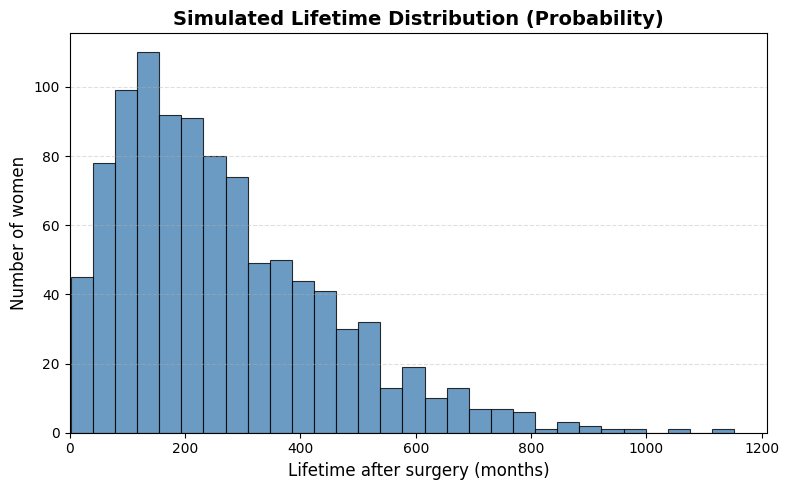

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    life_time,
    bins=30,
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
)

plt.xlabel("Lifetime after surgery (months)", fontsize=12)
plt.ylabel("Number of women", fontsize=12)
plt.title("Simulated Lifetime Distribution (Probability)", fontsize=14, weight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xlim(left=0)  # Remove if negative values are possible

plt.tight_layout()
plt.show()

In [9]:
frac_local = women_with_local_cancer/n
print(f"Fraction of the simulated women where local cancer reappered: {frac_local}")

Fraction of the simulated women where local cancer reappered: 0.712


## Task 2

In [69]:
# Theoretical distribution at time 120 
p0 = np.array([1, 0, 0, 0, 0])
n = 1000
t = 120  #Months

Pt = np.linalg.matrix_power(P, t)
exp_state_120 = (p0 @ Pt)
print(f"\nt = {t} months")
print("Theorical state distribution")
print(f"{exp_state_120}")




t = 120 months
Theorical state distribution
[0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


In [11]:
# Emperical distribution of 1000 simulated women at t = 120
np.random.seed(42)
n = 1000
emp_state_120 = []
for i in range(n):
    X = sim_liftime_women(P)
    if len(X)>= 120: #Check i woman is alive at t = 120
        emp_state_120.append(X[119])
    else:
        emp_state_120.append(4)

observed_120 = np.bincount(emp_state_120)
print(f"\nt = 120 months")
print("Emperical state distribution")
print(f"{observed_120}")


t = 120 months
Emperical state distribution
[365 167 170  67 231]


In [ ]:
# Do a chi-square test to see if distributions align
_, p_value_chi = chisquare(f_obs=observed_120, f_exp=exp_state_120)
print(f"Results of chi square test {p_value_chi}")

Results of chi square test 0.7729796996445759


## Task 3

In [15]:
# Theoretical lifetime distribution
pi= np.array([1, 0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910]
])
ps= np.array([0.0010, 0.0050, 0.0050, 0.0090])

exp_pdf = []
for t in range(1, np.max(life_time) + 1):
    prop = pi@np.linalg.matrix_power(Ps,t)@ps
    exp_pdf.append(prop)


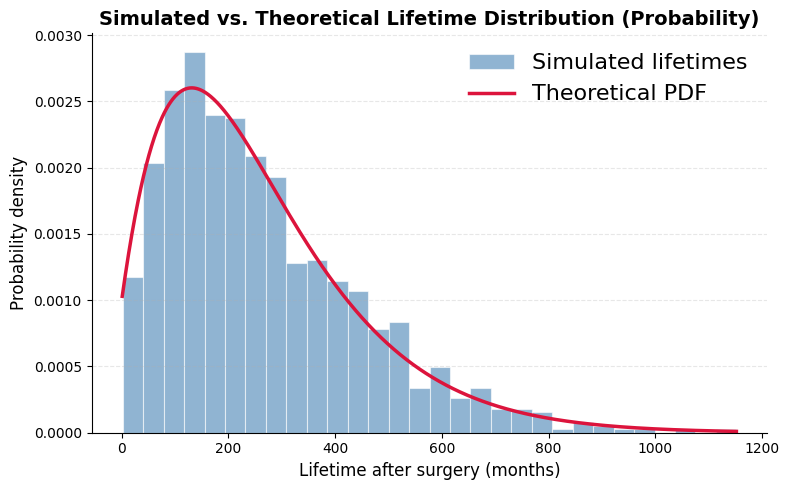

In [61]:
# Histogram with emperical lifetime and theoretical lifetime distribution 

x = np.arange(1, np.max(life_time) + 1)


fig, ax = plt.subplots(figsize=(8, 5))

# Histogram
ax.hist(
    life_time,
    bins=30,
    density=True,
    color="steelblue",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.8,
    label="Simulated lifetimes",
)

# Theoretical PDF
ax.plot(x,                
    exp_pdf,
    color="crimson",
    linewidth=2.5,
    label="Theoretical PDF",
)

# Labels and formatting
ax.set_xlabel("Lifetime after surgery (months)", fontsize=12)
ax.set_ylabel("Probability density", fontsize=12)
ax.set_title("Simulated vs. Theoretical Lifetime Distribution (Probability)",
             fontsize=14, weight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize = 16 )

plt.tight_layout()
plt.show()

## Task 4 

In [ ]:
# Simulate 1000 women who survives first 12 months but breast cancer 
# has reappered within the first 12 months (distant or locally)
np.random.seed(42)
women_cancer_again_lifetimes = [] # Store state history of the womans
while len(women_cancer_again_lifetimes) != 1000: 
    X = sim_liftime_women(P)
    if (1 in X[:12]) and (len(X) > 12):
        women_cancer_again_lifetimes.append(len(X))

    elif (2 in X[:12]) and (len(X) > 12):
        women_cancer_again_lifetimes.append(len(X))

    elif (3 in X[:12]) and (len(X) > 12):
        women_cancer_again_lifetimes.append(len(X))


In [ ]:
# Estimate expected life time
lifetime_mean_again = np.mean(women_cancer_again_lifetimes)
lifetime_mean = np.mean(life_time)
print(f"Estimated life time of woman with cancer again within 12 months {lifetime_mean_again} ")
print(f"Estimated life time of woman {lifetime_mean}")

Estimated life time of woman with cancer again within 12 months 179.99 
Estimated life time of woman 266.035


## Task 5 

In [ ]:
# Crude monte carlo estimator 
def crude_monte_carlo(n, n_womens):
    # Input: n: number of monte carlo estimators, n_womens: number of womans to simulate
    # Output: Mean of MC estimate of fraction of women die within the first 350 months,
    #       variance of the MC estimations 

    fractions = []
    for _ in range(n):
        dead_after_350 = 0
        for _ in range(n_womens):
            X = sim_liftime_women(P)
            if len(X) <350:
                dead_after_350 += 1
        fractions.append(dead_after_350/200)
    
    return np.mean(fractions), np.var(fractions, ddof = 1)

In [ ]:
# Result of crude monte carlo estimator 
np.random.seed(42)
n_womens = 200
n = 100
MC_mean, MC_var = crude_monte_carlo(n,n_womens)
print(f"Monte carlo estimation: {MC_mean}")
print(f"Variance of monto carlo estimation {MC_var}")

Monte carlo estimation: 0.7348)
Variance of monto carlo estimation 0.0012544600000000006


In [ ]:
# Theorical expected value of the life times of the women 
m = np.linalg.inv(np.eye(4)-Ps)
mu = pi@m@np.ones(4)

# Impose control variate to reduce variance of estimation
def control_variate(n,n_womens): 
    # Input: n: number of control variate estimators, n_womens: number of womans to simulate
    # Output: Mean of CV estimate of fraction of women die within the first 350 months,
    #       variance of the VC estimations 

    fractions = []
    for _ in range(n):
        X = np.zeros(n_womens) # Indikator variable we want to estimate mean of
        Z = [] # Life times of woman 
        for i in range(n_womens):
            women = sim_liftime_women(P)
            Z.append(len(women))
            if len(women) < 350:
                X[i] = 1
        
        c = - np.cov(X,Z)[0,1]/np.var(Z)

        Y = X + c*(Z - mu)
        frac = np.mean(Y)
        fractions.append(frac)
    
    return np.mean(fractions), np.var(fractions, ddof = 1)
            

In [27]:
# Do control variate simulation 
np.random.seed(4)
n = 100
n_womens = 200
CV_mean, CV_var = control_variate(n,n_womens)
print(f"Control variate estimation: {CV_mean}")
print(f"Variance of control variate estimation {CV_var}")

Control variate estimation: 0.7354455186671881
Variance of control variate estimation 0.00038468179838259246


## Task 6 

- Only register once a month, som states not registeret (may be incoorporated in probability matrix) - improvement (continues)
- In Markov chain assume that you propability of next chain only depend on current state and not the previous (might not be the case)
- P does not depend on time, but in general the older you become the higher the probability of cancer and death. Also right after operation higher propability of cancer again than if diases free along time  - could make probability matrix different depending of time (But this is hard task)
- We assume homegenous population (every women is a like, this is not the case)

# Part 2: A continuous-time model

## Task 7

In [32]:
# Function to compute 95 confidence interval for mean 
def confidence_interval_95(results):
    # Input: list of results 
    # Output: 95 CI of mean of results 
    results = np.asarray(results)
    n = len(results)

    mean = np.mean(results)
    std = np.std(results, ddof=1)

    t_crit = stats.t.ppf(0.975, df=n-1)

    margin = t_crit * std / np.sqrt(n)

    return (mean - margin, mean + margin)

# Function to compute 95 confidence interval for std 

def confidence_interval_std_95(results):
    # Input: list of results 
    # Output: 95 CI of std of results 
    
    results = np.asarray(results)
    n = len(results)

    s = np.std(results, ddof=1)

    chi2_lower = stats.chi2.ppf(0.025, df=n-1)
    chi2_upper = stats.chi2.ppf(0.975, df=n-1)

    lower = np.sqrt((n - 1) * s**2 / chi2_upper)
    upper = np.sqrt((n - 1) * s**2 / chi2_lower)

    return (lower, upper)


In [33]:
# Function that simulates states of a woman using transistion rates 

def sim_liftime_women_rate(Q):
   # Input: Q: Transition rate matrix 
   # Output: History of a woman that is a list of tuples (time, state)
   state = 0
   time = 0 
   history = [(time,state)]


   while state != 4:
      rate = -Q[state,state]

      wait = np.random.exponential(1/rate)
      time += wait 

      probs = Q[state].copy()
      probs[state] = 0 

      probs = probs/rate

      state = np.random.choice(np.arange(5), p = probs)
      history.append((time,state))
      

   return history

In [34]:
np.random.seed(42)

Q = np.array([
    [-0.0085,  0.0050,  0.0025, 0.0000, 0.0010],
    [ 0.0000, -0.0140,  0.0050, 0.0040, 0.0050],
    [ 0.0000,  0.0000, -0.0080, 0.0030, 0.0050],
    [ 0.0000,  0.0000,  0.0000, -0.0090, 0.0090],
    [ 0.0000,  0.0000,  0.0000, 0.0000, 0.0000]
])

n = 1000
life_time_rate= []

reapar_dist = 0 
for i in range(n):
    X = sim_liftime_women_rate(Q)
    life_time_rate.append(X[-1][0])
    for time,s in X:
        if time <= 30.5 and s in [2,3]:
            reapar_dist += 1 
            break

lifetimes_rate = np.array(life_time_rate)
mean_life =  np.mean(lifetimes_rate)
conf_mean_life = confidence_interval_95(lifetimes_rate)
std_life = np.std(lifetimes_rate,  ddof=1)
cond_std_life = confidence_interval_std_95(lifetimes_rate)
dist_cancer_again = reapar_dist/n
print(f"Life time mean {mean_life}")
print(f"Life time confidence interval for mean [{conf_mean_life}]")
print(f"Life time std {std_life}")  
print(f"Life time confidence interval for std [{cond_std_life}]")
print(f"Fraction of distant cancer again {dist_cancer_again}")


Life time mean 256.3715684046518
Life time confidence interval for mean [(np.float64(244.30943097040765), np.float64(268.43370583889595))]
Life time std 194.37915621555038
Life time confidence interval for std [(np.float64(186.2176320670264), np.float64(203.29442568598935))]
Fraction of distant cancer again 0.084


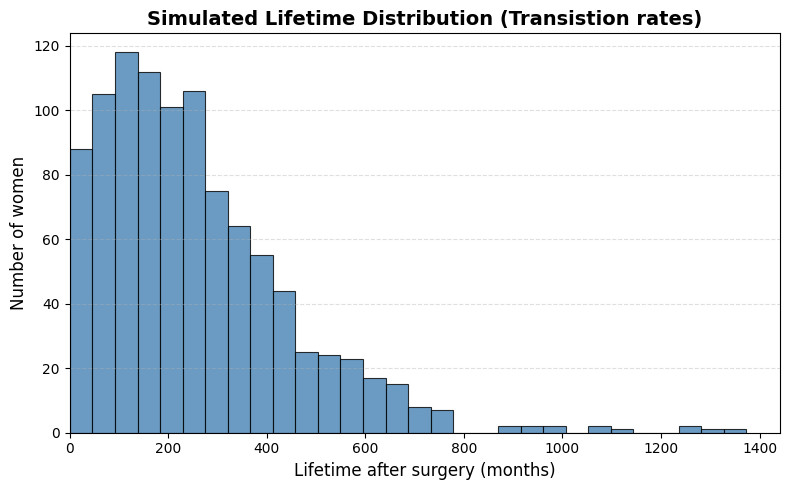

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    lifetimes_rate,
    bins=30,
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
)

plt.xlabel("Lifetime after surgery (months)", fontsize=12)
plt.ylabel("Number of women", fontsize=12)
plt.title("Simulated Lifetime Distribution (Transistion rates)", fontsize=14, weight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xlim(left=0)  # Remove if negative values are possible

plt.tight_layout()
plt.show()

## Task 8 

In [ ]:
# Compute theorical distribution
Qs = np.array([
    [-0.0085, 0.0050, 0.0025, 0.0000],
    [ 0.0000,-0.0140, 0.0050, 0.0040],
    [ 0.0000, 0.0000,-0.0080, 0.0030],
    [ 0.0000, 0.0000, 0.0000,-0.0090]
])

p0 = np.array([1, 0, 0, 0])

# make smooth time grid
max_t = np.max(life_time_rate)
times = np.linspace(0, max_t, 300)   

# compute CDF
F_cdf = []

for t in times:
    val = 1 - p0 @ scipy.linalg.expm(Qs * t) @ np.ones(4)
    F_cdf.append(val)

F_cdf = np.array(F_cdf)

# convert CDF to PDF
pdf = np.gradient(F_cdf, times)



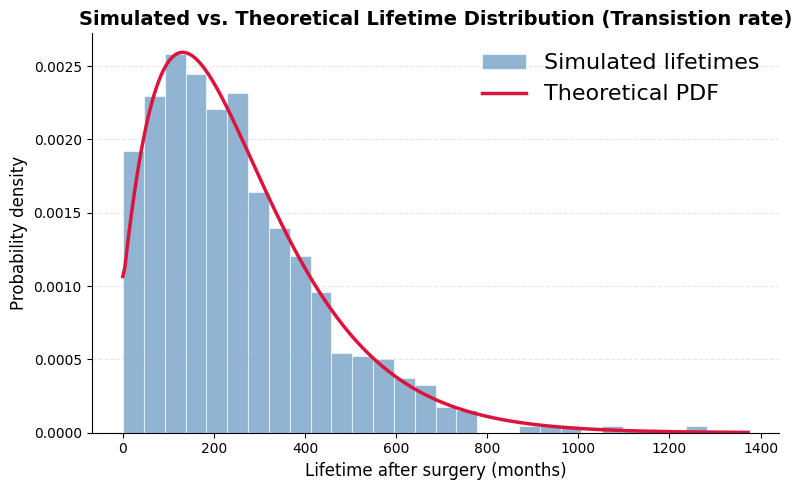

In [60]:
# Plot emperical and theorical distribution 
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram
ax.hist(
    life_time_rate,
    bins=30,
    density=True,
    color="steelblue",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.8,
    label="Simulated lifetimes",
)

# Theoretical PDF
ax.plot(times, pdf,
    color="crimson",
    linewidth=2.5,
    label="Theoretical PDF",
)

# Labels and formatting
ax.set_xlabel("Lifetime after surgery (months)", fontsize=12)
ax.set_ylabel("Probability density", fontsize=12)
ax.set_title("Simulated vs. Theoretical Lifetime Distribution (Transistion rate)",
             fontsize=14, weight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize = 16)

plt.tight_layout()
plt.show()


In [46]:
# Chi-square test 

bins = np.linspace(0, np.max(life_time_rate), 10)

obs_counts, _ = np.histogram(life_time_rate, bins=bins)

# Compute expected counts 
expected_counts = []

for i in range(len(bins) - 1):
    t1, t2 = bins[i], bins[i+1]

    F1 = 1 - p0 @ scipy.linalg.expm(Qs * t1) @ np.ones(4)
    F2 = 1 - p0 @ scipy.linalg.expm(Qs * t2) @ np.ones(4)

    expected_counts.append(len(life_time_rate) * (F2 - F1))

expected_counts = np.array(expected_counts)

mask = expected_counts >= 5

obs_counts = obs_counts[mask]
expected_counts = expected_counts[mask]

chi2_stat = np.sum((obs_counts - expected_counts)**2 / expected_counts)

df = len(obs_counts) - 1

p_value = 1 - stats.chi2.cdf(chi2_stat, df=df)

print("Chi-square:", chi2_stat)
print("p-value:", p_value)

Chi-square: 7.233608036637046
p-value: 0.20383822622164127


## Task 9 

In [52]:
# Compute diagonal elements
def diag_elements_add(Q):
    # Input: Q matrix with 0 in in diagonal 
    # Output: Q matrix with correctly filled diagonal 
    for i in range(np.shape(Q)[0]):
        Q[i,i] = -np.sum(Q[i])
    
    return Q

In [53]:
# Find correct Q matrix with filled diagonals 
Q = np.array([
    [0.0000, 0.0025, 0.00125, 0.0000, 0.0010],
    [0.0000, 0.0000, 0.0000, 0.0020, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]
])

Q_diag = diag_elements_add(Q)
Q_diag

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])

In [54]:
# Simulate 1000 womans with treatment life times 
np.random.seed(42)
n = 1000
life_time_treat= []

for i in range(n):
    X = sim_liftime_women_rate(Q_diag)
    life_time_treat.append(X[-1][0])
   

life_time_treat = np.array(life_time_treat)

In [55]:
# d(t) is the number of women who have died at time t.
def d_t(life_time, t):
    # Input: life_time: list of life times of the woman, t: time t
    # Output:  Number of women who have died at time t
    s =life_time<=t
    return np.sum(s)

In [56]:
# Surval function of woman with treatmeant 
max_t_treatment = np.max(life_time_treat)
times_treatment = np.linspace(0, max_t, 1000)   
n = 1000
surval_treatment = []
for t in times_treatment:
    s = (n-d_t(life_time_treat, t))/n
    surval_treatment.append(s)

# Surval function of woman without treatment 
max_t_rate = np.max(life_time_rate)
times_rate = np.linspace(0, max_t, 1000)   
n = 1000
surval_rate = []
for t in times_rate:
    s = (n-d_t(life_time_rate, t))/n
    surval_rate.append(s)
    


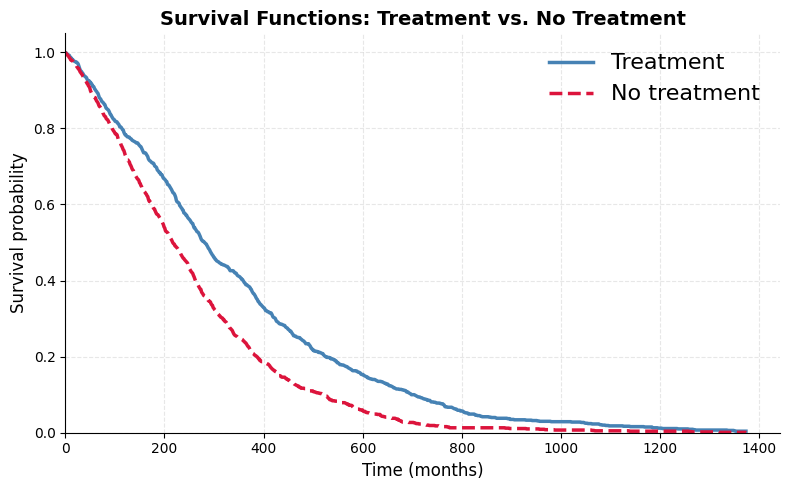

In [59]:

fig, ax = plt.subplots(figsize=(8, 5))

# Survival curves
ax.plot(
    times_treatment,
    surval_treatment,
    color="steelblue",
    linewidth=2.5,
    label="Treatment"
)

ax.plot(
    times_rate,
    surval_rate,
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label="No treatment"
)

# Labels and title
ax.set_title(
    "Survival Functions: Treatment vs. No Treatment",
    fontsize=14,
    weight="bold"
)
ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Survival probability", fontsize=12)

# Formatting
ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)
ax.grid(axis="both", linestyle="--", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=16)

plt.tight_layout()
plt.show()

## Task 11 

- Fixed time step, that cancer does only appear and disappear in one month time intervals 
- Assume that the time you stay in a state is exponentially distributed 
- Do waiting through Erlang distribution

# Part 3: Estimation

## Task 12

In [ ]:
np.random.seed(42)

Simulations = [] # Stores times series for 1000 woman 
Q = np.array([
    [-0.0085,  0.0050,  0.0025, 0.0000, 0.0010],
    [ 0.0000, -0.0140,  0.0050, 0.0040, 0.0050],
    [ 0.0000,  0.0000, -0.0080, 0.0030, 0.0050],
    [ 0.0000,  0.0000,  0.0000, -0.0090, 0.0090],
    [ 0.0000,  0.0000,  0.0000, 0.0000, 0.0000]
])


# Compute times series for every woman 
for _ in range(1000):

    X = sim_liftime_women_rate(Q)

    Yi = []
    i = 0

    for t in np.arange(0, X[-1][0] + 48, 48):

        while i + 1 < len(X) and X[i + 1][0] <= t:
            i += 1

        Yi.append(X[i][1])

        if Yi[-1] == 4: # if woman dead stop 
            break

    Simulations.append(Yi)

In [ ]:
# For each of the women, create a vector (or time series) of her observed states Y(i), i = 0, 48, 96, ... until death
Simulations

[[0, 0, np.int64(4)],
 [0, 0, 0, 0, np.int64(4)],
 [0, 0, 0, np.int64(4)],
 [0, 0, 0, 0, 0, np.int64(2), np.int64(4)],
 [0, 0, np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(4)],
 [0, np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(4)],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(4)],
 [0, np.int64(4)],
 [0, np.int64(2), np.int64(4)],
 [0,
  0,
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(4)],
 [0, 0, 0, 0, 0, 0, 0, np.int64(4)],
 [0, 0, 0, np.int64(4)],
 [0,
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(4)],
 [0, np.int64(1), np.int64(4)],
 [0, np.int64(4)],
 [0, 0, 0, 0, np.int64(4)],
 [0, 0, 0, 0, np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(4)],
 [0, 0, 0, 0, 0, np.int64(2), np.int64(3), np.int64(4)],
 [0,
  0,
  0,
  0,
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int6

# Task 13

In [ ]:
# XXX - comment on this code 
def simulate_markov(X0, X_end, Q, t):

    state = X0
    time = 48 * t
    end_time = 48 * (t + 1)

    history = [(time, state)]

    while True:

        rate = -Q[state, state]

        if state == 4:  # No going on after death
            break

        wait = np.random.exponential(1 / rate)

        if time + wait > end_time:
            break

        time += wait

        probs = Q[state].copy()
        probs[state] = 0
        probs /= rate

        state = np.random.choice(len(Q), p=probs)

        history.append((time, state))

    # state at end_time
    if state == X_end:
        return history
    else:
        return False

In [66]:
def create_Q(maxiter, eps, Q0):
    Q = Q0
    k =0
    dif = np.inf

    while (k <= maxiter) and (dif >=eps):
        # create the full Markov chain for all women
        all_women = []
        for woman in Simulations: 
            history = [(0,0)]
            for t in range(len(woman[:-1])): 
                his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                while his_subset == False: 
                    his_subset =simulate_markov(woman[t],woman[t+1],Q,t)
                history.extend(his_subset[1:])
            all_women.append(history)

        N = np.zeros(np.shape(Q))
        S = np.zeros(np.shape(Q)[0])


        for path in all_women:
            for (t1, s1), (t2, s2) in zip(path[:-1], path[1:]):
                if s1 != s2:
                    N[s1, s2]+=1
                    duration = t2-t1
                    S[s1] +=duration
        
        for i in range(len(S)-1):
            N[i] = N[i]/S[i]

        diag_elements_add(N)

        dif = np.linalg.norm((Q-N),ord=np.inf)
        k+=1
        Q = N 

    return Q

In [67]:
Q0 = np.array([
    [-0.04, 0.01, 0.01, 0.01,   0.01],
    [0.0, -0.03,    0.01,     0.01, 0.01],
    [0.0, 0.0,    -0.02,     0.01, 0.01],
    [0.0, 0.0,    0.0,     -0.01,   0.01],
    [0.0, 0.0,    0.0,     0.0,   0.0]
])
np.random.seed(42)
create_Q(10000,10**(-3) , Q0)

array([[-0.00846679,  0.00489381,  0.0023453 ,  0.00028787,  0.00093981],
       [ 0.        , -0.01441026,  0.00565939,  0.00361503,  0.00513584],
       [ 0.        ,  0.        , -0.00823644,  0.00277816,  0.00545828],
       [ 0.        ,  0.        ,  0.        , -0.0093765 ,  0.0093765 ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.        ]])

In [68]:
Q

array([[-0.0085,  0.005 ,  0.0025,  0.    ,  0.001 ],
       [ 0.    , -0.014 ,  0.005 ,  0.004 ,  0.005 ],
       [ 0.    ,  0.    , -0.008 ,  0.003 ,  0.005 ],
       [ 0.    ,  0.    ,  0.    , -0.009 ,  0.009 ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]])